In [313]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy
import seaborn as sns
import statsmodels.formula.api as smf

*** ***

In [314]:
NUMBER_OF_OBSERVATIONAL_SAMPLES = 10000

In [315]:
class SCM:
    def __init__(self):
        self.variables = {}

    def add_variable(self, name, parents, equation):
        self.variables[name] = {
            "parents": parents,
            "equation": equation
        }

    def get_topological_order(self):
        graph = nx.DiGraph()
        for variable, info in self.variables.items():
            graph.add_node(variable)
            for parent in info["parents"]:
                graph.add_edge(parent, variable)
        return list(nx.topological_sort(graph))
    
    def sample(self, n_samples):
        order = self.get_topological_order()
        samples = []
        for _ in range(n_samples):
            row = {}
            for variable in order:
                equation = self.variables[variable]["equation"]
                row[variable] = equation(row)
            samples.append(row)
        return pd.DataFrame(samples)

    def do_operator(self, interventions):
        new_scm = deepcopy(self)
        for variable, value in interventions.items():
            new_scm.variables[variable]["parents"] = []
            new_scm.variables[variable]["equation"] = (lambda d, v=value:v)
        return new_scm

    def plot_graph(self, title="SCM"):
        graph = nx.DiGraph()
        for variable, info in self.variables.items():
            graph.add_node(variable)
            for parent in info["parents"]:
                graph.add_edge(parent, variable)
        plt.figure(figsize=(8,6))
        pos = nx.spring_layout(graph)
        nx.draw(graph, pos, with_labels=True, node_size=2500, node_color="skyblue", font_size=12, font_weight="bold", arrowsize=20)
        plt.title(title, fontsize=14)
        plt.show()

*** ***

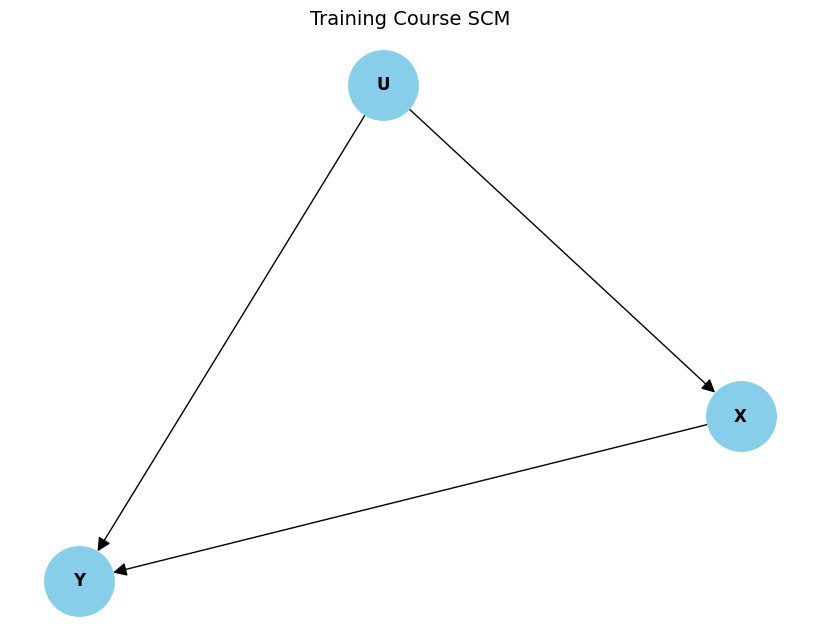

In [ ]:
scm = SCM()
scm.add_variable("U",[], lambda d: np.random.normal(0,1))
scm.add_variable("X", ["U"], lambda d: 7*d["U"] + np.random.normal(0,1) > 0)
scm.add_variable("Y", ["X","U"], lambda d: 3*d["X"] + 2*d["U"] + np.random.normal(0,1))

scm.plot_graph("Training Course SCM")

In [317]:
observational_data = scm.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)
observational_data.head()

,U,X,Y
0,-2.635612,False,-5.278651
1,0.160845,True,1.640465
2,1.927164,True,8.488907
3,0.188527,True,3.339134
4,-0.606901,False,-3.909879


In [318]:
E_Y_given_X1 = observational_data[observational_data["X"] ==1]["Y"].mean()
E_Y_given_X0 = observational_data[observational_data["X"] ==0]["Y"].mean()
observational_effect = (E_Y_given_X1 - E_Y_given_X0)
print(f"E[Y|X=1] = {E_Y_given_X1:.5f}")
print(f"E[Y|X=0] = {E_Y_given_X0:.5f}")
print(f"Observational effect = {observational_effect:.5f}")

E[Y|X=1] = 4.59112
E[Y|X=0] = -1.60224
Observational effect = 6.19336


*** ***

In [319]:
scm_do1 = scm.do_operator({"X":1})
data_do1 = scm_do1.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)
mean_do1 = data_do1["Y"].mean()

In [320]:
scm_do0 = scm.do_operator({"X":0})
data_do0 = scm_do0.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)
mean_do0 = data_do0["Y"].mean()

In [321]:
print(f"E[Y|do (X=1)] = {mean_do1:.5f}")
print(f"E[Y|do (X=0)] = {mean_do0:.5f}")
ATE = mean_do1 - mean_do0
print(f"ATE = {ATE:.5f}")

E[Y|do (X=1)] = 2.99142
E[Y|do (X=0)] = 0.05267
ATE = 2.93875


*** ***

In [353]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [354]:
disease_scm = SCM()
disease_scm.add_variable("Age", [], lambda d: np.random.normal(50,10))
disease_scm.add_variable("SES", [], lambda d: np.random.normal(0,1))
disease_scm.add_variable("Genetics", [], lambda d: np.random.normal(0,1))
disease_scm.add_variable("Smoking", ["Age","SES"], lambda d: np.random.uniform(0,1) < sigmoid(-2 + 0.03*d["Age"] - 0.5*d["SES"]))
disease_scm.add_variable("BMI", ["Smoking","SES"], lambda d: 25 + 2*d["Smoking"] - d["SES"] + np.random.normal(0,3))
disease_scm.add_variable("BP", ["Smoking","Age","Genetics"], lambda d: 120 + 5*d["Smoking"] +0.3*d["Age"] + 2*d["Genetics"] + np.random.normal(0,10))
disease_scm.add_variable("Cholesterol", ["Smoking","BMI"], lambda d: 180 + 10*d["Smoking"] - 0.5*d["BMI"] + np.random.normal(0,15))
disease_scm.add_variable("Disease", ["Smoking","Age","BMI","BP","Cholesterol","Genetics"], 
                    lambda d: sigmoid(-15+ 0.6*d["Smoking"] + +0.02*d["Age"] + 0.01*d["BMI"] + 0.03*d["BP"] + 0.04*d["Cholesterol"] + 0.2*d["Genetics"]))

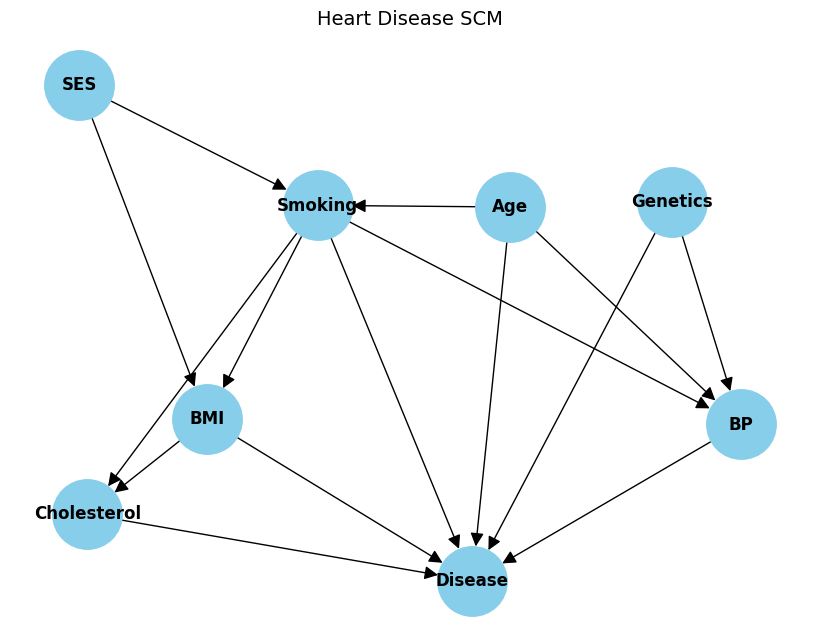

In [358]:
disease_scm.plot_graph("Heart Disease SCM")

In [359]:
observational_data = disease_scm.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)
observational_data.head()

,Age,SES,Genetics,Smoking,BMI,BP,Cholesterol,Disease
0,59.548308,-0.792864,-1.204646,True,27.052003,133.831972,155.149337,0.049336
1,56.707538,-0.167077,0.476952,False,25.468741,130.506417,170.120748,0.057554
2,54.399316,0.449068,0.603591,False,22.188695,138.759982,176.564932,0.087543
3,45.222390,1.461427,1.550928,False,19.916478,148.097720,158.047477,0.056180
4,53.439473,-0.419336,-1.219661,False,29.149174,129.132380,161.114129,0.027515


In [360]:
do_smoke1 = disease_scm.do_operator({"Smoking":1})
data_smoke1 = do_smoke1.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)

In [361]:
do_smoke0 = disease_scm.do_operator({"Smoking":0})
data_smoke0 = do_smoke0.sample(NUMBER_OF_OBSERVATIONAL_SAMPLES)

In [362]:
mean_data_smoke_1 = data_smoke1["Disease"].mean()
mean_data_smoke_0 = data_smoke0["Disease"].mean()
ATE = (mean_data_smoke_1 - mean_data_smoke_0)
print(f"E[Disease|do (Smoking=1)] = {mean_data_smoke_1:.5f}")
print(f"E[Disease|do (Smoking=0)] = {mean_data_smoke_0:.5f}")
print(f"ATE = {ATE:.5f}")

E[Disease|do (Smoking=1)] = 0.15634
E[Disease|do (Smoking=0)] = 0.06010
ATE = 0.09624


In [368]:
real_smokers = observational_data[observational_data["Smoking"] == 1].copy()

In [369]:
mean_do1_smokers = real_smokers["Disease"].mean()
counterfactual_samples = []
for _, row in real_smokers.iterrows():
    cf_row = {}
    cf_row["Age"] = row["Age"]
    cf_row["SES"] = row["SES"]
    cf_row["Genetics"] = row["Genetics"]
    cf_row["Smoking"] = 0
    cf_row["BMI"] = disease_scm.variables["BMI"]["equation"](cf_row)
    cf_row["BP"] = disease_scm.variables["BP"]["equation"](cf_row)
    cf_row["Cholesterol"] = disease_scm.variables["Cholesterol"]["equation"](cf_row)
    cf_row["Disease"] = disease_scm.variables["Disease"]["equation"](cf_row)
    counterfactual_samples.append(cf_row)
cf_df = pd.DataFrame(counterfactual_samples)
mean_do0_smokers = cf_df["Disease"].mean()
ATT = mean_do1_smokers - mean_do0_smokers

print(f"E[D|do(Smoking=1), Smoking=1] = {mean_do1_smokers:.5f}")
print(f"E[D|do(Smoking=0), Smoking=1] = {mean_do0_smokers:.5f}")
print(f"ATT = {ATT:.5f}")

E[D|do(Smoking=1), Smoking=1] = 0.16275
E[D|do(Smoking=0), Smoking=1] = 0.06211
ATT = 0.10065


In [372]:
mean_do1_eldery = data_smoke1[data_smoke1["Age"] > 55]["Disease"].mean()
mean_do0_eldery = data_smoke0[data_smoke0["Age"] > 55]["Disease"].mean()
CATE_older = mean_do1_eldery - mean_do0_eldery

print(f"E[D|do(Smoking=1), Age>55] = {mean_do1_eldery:.5f}")
print(f"E[D|do(Smoking=0), Age>55] = {mean_do0_eldery:.5f}")
print(f"CATE(Age > 55) = {CATE_older:.5f}")

E[D|do(Smoking=1), Age>55] = 0.20185
E[D|do(Smoking=0), Age>55] = 0.08083
CATE(Age > 55) = 0.12102


In [367]:
mean_do1_younger = data_smoke1[data_smoke1["Age"] <= 55]["Disease"].mean()
mean_do0_younger = data_smoke0[data_smoke0["Age"] <= 55]["Disease"].mean()
CATE_younger = mean_do1_younger - mean_do0_younger

print(f"E[D|do(Smoking=1), Age<=55] = {mean_do1_younger:.5f}")
print(f"E[D|do(Smoking=0), Age<=55] = {mean_do0_younger:.5f}")
print(f"CATE (Age <= 55) = {CATE_younger:.5f}")

E[D|do(Smoking=1), Age<=55] = 0.13660
E[D|do(Smoking=0), Age<=55] = 0.05133
CATE (Age <= 55) = 0.08527


*** ***

In [333]:
website_df = pd.read_csv("website_engagement_data.csv")
website_df.head()

,user_id,age_group,layout,time_spent
0,1001,Young,Old_Layout,13.68
1,1002,Older,New_Layout,6.76
2,1003,Older,Old_Layout,4.66
3,1004,Older,New_Layout,8.55
4,1005,Young,New_Layout,19.37


In [334]:
print(website_df.columns)

Index(['user_id', 'age_group', 'layout', 'time_spent'], dtype='str')


***Naive analysis***

In [335]:
mean_times = website_df.groupby("layout")["time_spent"].mean()

In [336]:
old_layout_mean = mean_times["Old_Layout"]
new_layout_mean = mean_times["New_Layout"]
print(f"Old Layout: {old_layout_mean:.4f}")
print(f"New Layout: {new_layout_mean:.4f}")
print(f"Difference: {(new_layout_mean - old_layout_mean):.4f}")

Old Layout: 12.5017
New Layout: 9.7305
Difference: -2.7712


In [337]:
website_df["layout_new"] = (website_df["layout"] == "New_Layout").astype(int)
naive_model = smf.ols("time_spent ~ layout_new", data=website_df).fit()
print(naive_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.5017      0.207     60.422      0.000      12.096      12.908
layout_new    -2.7712      0.275    -10.085      0.000      -3.310      -2.232


In [338]:
print(f"Layout Coefficient:{naive_model.params["layout_new"]:.4f}")
print("p-value:",naive_model.pvalues["layout_new"])

Layout Coefficient:-2.7712
p-value: 7.644394645860548e-23


***Visual recognition***

In [339]:
pd.crosstab(website_df["age_group"], website_df["layout"], normalize="columns") * 100

layout,New_Layout,Old_Layout
age_group,,
Older,83.068783,24.942263
Young,16.931217,75.057737


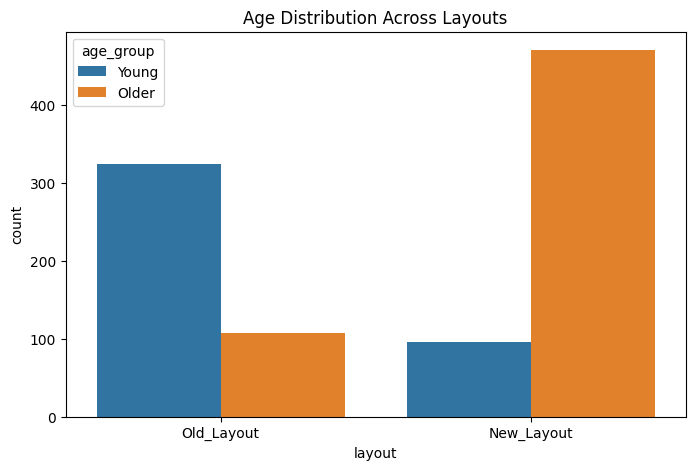

In [340]:
plt.figure(figsize=(8,5))
sns.countplot(data=website_df, x="layout", hue="age_group")
plt.title("Age Distribution Across Layouts")
plt.show()

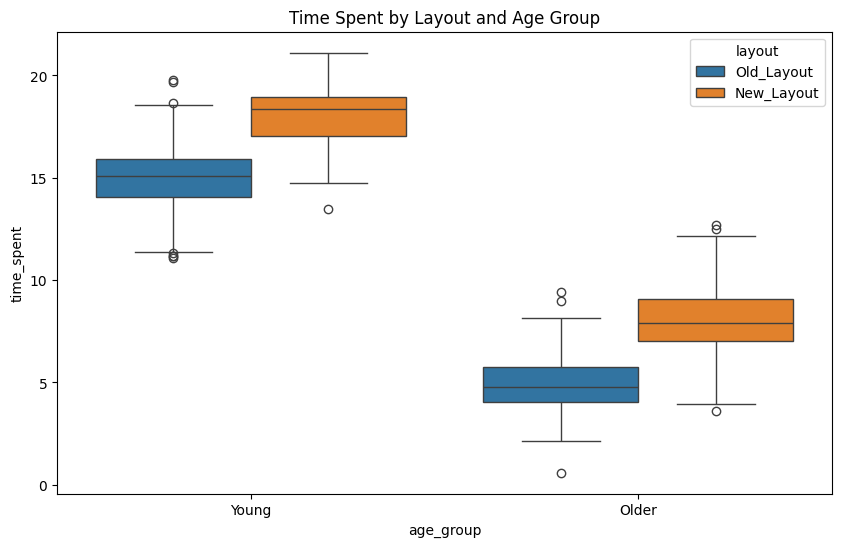

In [341]:
plt.figure(figsize=(10,6))
sns.boxplot(data=website_df, x="age_group", y="time_spent", hue="layout")
plt.title("Time Spent by Layout and Age Group")
plt.show()

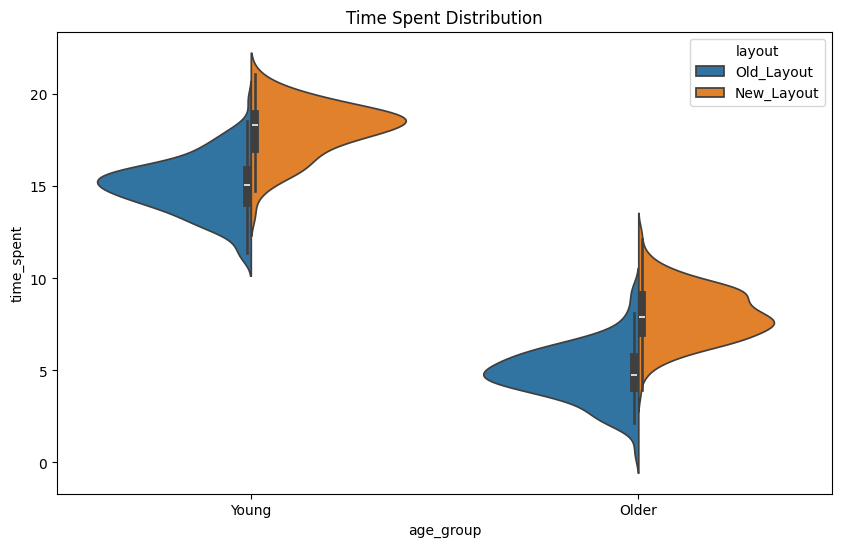

In [342]:
plt.figure(figsize=(10,6))
sns.violinplot(data=website_df, x="age_group", y="time_spent", hue="layout", split=True)
plt.title("Time Spent Distribution")
plt.show()

In [343]:
group_means = website_df.groupby(["age_group", "layout"])["time_spent"].mean()
print(group_means)

age_group  layout    
Older      New_Layout     8.035499
           Old_Layout     4.879815
Young      New_Layout    18.046875
           Old_Layout    15.034554
Name: time_spent, dtype: float64


***Causal analysis***

In [344]:
website_df["older"] = (website_df["age_group"] == "Older").astype(int)

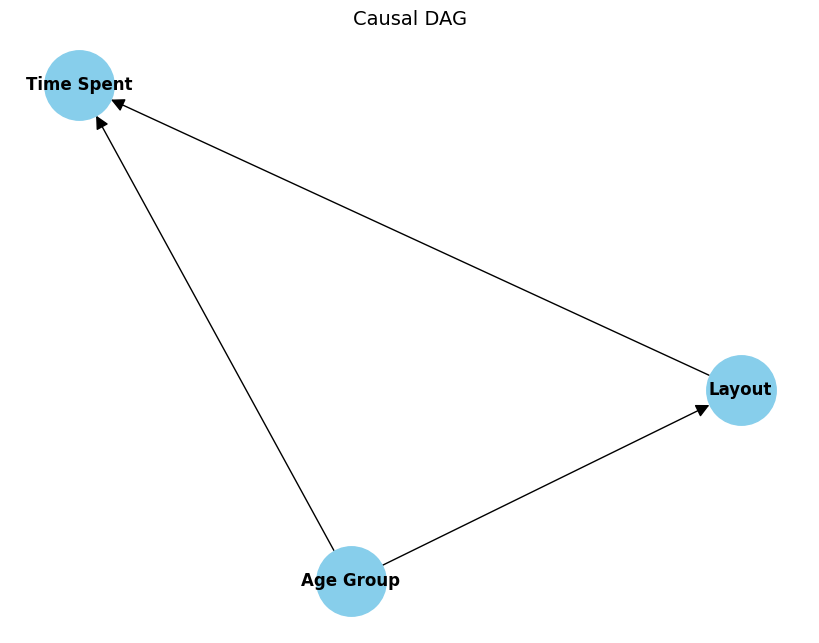

In [345]:
website_scm = SCM()
website_scm.add_variable("Age Group", [], lambda: None)
website_scm.add_variable("Layout", ["Age Group"], lambda: None)
website_scm.add_variable("Time Spent", ["Age Group","Layout"], lambda: None)
website_scm.plot_graph("Causal DAG")

In [346]:
causal_model = smf.ols("time_spent ~ layout_new + older", data=website_df).fit()
print(causal_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.0168      0.076    196.986      0.000      14.867      15.166
layout_new     3.0901      0.115     26.787      0.000       2.864       3.316
older        -10.0836      0.116    -87.099      0.000     -10.311      -9.856


In [347]:
print(f"Naive coefficient:{naive_model.params["layout_new"]:.4f}")
print(f"Controlled coefficient:{causal_model.params["layout_new"]:.4f}")

Naive coefficient:-2.7712
Controlled coefficient:3.0901


In [348]:
print(f"Naive p-value:{naive_model.pvalues["layout_new"]:.4f}")
print(f"Controlled p-value:{causal_model.pvalues["layout_new"]:.4f}")

Naive p-value:0.0000
Controlled p-value:0.0000


***Placebo Test***

In [373]:
df_placebo = website_df.copy()
df_placebo["layout_new"] = np.random.permutation(df_placebo["layout_new"])

In [377]:
placebo_model = smf.ols( "time_spent ~ layout_new + older", data=df_placebo).fit()
print(placebo_model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.6515      0.117    134.335      0.000      15.423      15.880
layout_new     0.1242      0.123      1.012      0.312      -0.117       0.365
older         -8.2754      0.123    -67.143      0.000      -8.517      -8.034


In [376]:
print(f"Naive coefficient:{naive_model.params["layout_new"]:.4f}")
print(f"Controlled coefficient:{causal_model.params["layout_new"]:.4f}")
print(f"Placebo coefficient:{placebo_model.params["layout_new"]:.4f}")

Naive coefficient:-2.7712
Controlled coefficient:3.0901
Placebo coefficient:0.1242
